# 🪙 Flipping Coins: Chance, Simulation, and Probability

In this notebook you'll flip *thousands* of coins without touching a single coin. Along the way you'll learn how statisticians talk about chance — and you'll discover one of the most important ideas in all of statistics.

## Setup

Import:
- **numpy** — makes random numbers (our "coin")
- **pandas** — organizes results into tables
- **matplotlib** and **seaborn** — draw graphs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Now, create our random number generator.

In [3]:
rng = np.random.default_rng()   # our random number generator

---
## Chance

Before we flip anything, we need some vocabulary.

### Random process:
A **random process** is anything whose result is decided by **chance**. You can't know the result ahead of time.

> 🪙 Flipping a coin is a random process. Before it lands, nobody knows if it'll be heads or tails.

Other examples: rolling a die, spinning a spinner, drawing a card from a shuffled deck.

### Trial and outcome
Doing the random process **one time** is called a **trial**. The result of one trial is called an **outcome**.

> 🪙 One flip = one trial. The outcome is either **Heads** or **Tails**.

### Event
An **event** is a **collection of outcomes**. More specifically, it's the group of outcomes we care about.

> 🎲 Imagine you want to know the chance of rolling an even number. Then, the **event** is made of three outcomes: {2, 4, 6}.

An event can be just one outcome, or a whole bunch of them.

---
## Sample Space

The **sample space** is the list of **every possible outcome** of a random process. No outcome is left out, and no two outcomes overlap (you can't get two of them at the same time).

> 🪙 For one coin flip, the sample space is **{Heads, Tails}**.

Because the sample space includes *everything* that can possibly happen, the probability that *something* in it happens is **1** (which means 100% — guaranteed).

In [5]:
sample_space = ["Heads", "Tails"]

print("Sample space for one coin flip:", sample_space)
print("Number of possible outcomes:", len(sample_space))

Sample space for one coin flip: ['Heads', 'Tails']
Number of possible outcomes: 2


What if we flip **two** coins? Now each outcome is a *pair* of results. Here is how we simulate this:

In [6]:
two_coin_space = []
for first in ["H", "T"]:
    for second in ["H", "T"]:
        two_coin_space.append(first + second)

print("Sample space for flipping two coins:", two_coin_space)
print("Number of possible outcomes:", len(two_coin_space))

Sample space for flipping two coins: ['HH', 'HT', 'TH', 'TT']
Number of possible outcomes: 4


Notice that **HT** and **TH** are *different* outcomes. Getting heads on the first coin and tails on the second is not the same as tails first and heads second. 

---
## Theoretical Probability

### Probability is a number from 0 to 1

| Probability | What it means |
|---|---|
| **0** | Impossible — it will never happen |
| **0.5** | A 50-50 chance |
| **1** | Certain — it will always happen |

A probability can **never** be negative and can **never** be bigger than 1.

### Calculating theoretical probability
If every outcome in the sample space is **equally likely** (like a fair coin), then:

$$P(E) = \frac{\text{number of outcomes in event } E}{\text{total number of outcomes in the sample space}}$$

We write "the probability of event E" as **P(E)**.

This is called the **theoretical probability**.

> 🪙 Let E = "the coin lands on Heads."
> - Outcomes in E: {Heads} → **1** outcome
> - Total outcomes: {Heads, Tails} → **2** outcomes
> - P(Heads) = 1/2 = **0.5**

In [7]:
outcomes_in_event = 1
total_outcomes = len(sample_space)

theoretical_p_heads = outcomes_in_event / total_outcomes
print("Theoretical P(Heads) =", theoretical_p_heads)

Theoretical P(Heads) = 0.5


---
## Simulation

Theory says P(Heads) = 0.5. But what actually happens when we flip a coin over and over? Instead of flipping a real coin hundreds of times, we can build a **simulation**.

### What is a simulation?
A **simulation** is a way to imitate a random process so that humans can observe the outcomes of events that would otherwise be taxing or dangerous to do by hand.

To set one up:
1. Give every outcome a value that the computer can pick by chance. We'll use:
   - **1 = Heads**
   - **0 = Tails**

   The computer picks 0 or 1 with equal chance.
2. Run the **trials** (flip the "coin" many times).
3. Record the count of each **outcome** and the total count.

In [8]:
def flip_coins(number_of_flips):
    # The computer picks 0 or 1 at random for each flip
    values = rng.integers(0, 2, size=number_of_flips)

    # Turn the numbers back into words so they're easier to read
    labels = np.where(values == 1, "Heads", "Tails")

    # Put the results in a dataframe, numbering each flip
    return pd.DataFrame({
        "flip_number": np.arange(1, number_of_flips + 1),
        "value": values,
        "outcome": labels
    })

# Flip 10 coins and look at every result
flips_10 = flip_coins(10)
flips_10

,flip_number,value,outcome
0,1,0,Tails
1,2,1,Heads
2,3,1,Heads
3,4,1,Heads
4,5,1,Heads
5,6,1,Heads
6,7,0,Tails
7,8,0,Tails
8,9,0,Tails
9,10,1,Heads


Each row is **one trial**, and the `outcome` column shows its result. Now let's **record the counts** of each outcome and the **total**.

In [9]:
counts_10 = flips_10["outcome"].value_counts()

print("Counts of each outcome:")
print(counts_10)
print()
print("Total number of flips:", counts_10.sum())

Counts of each outcome:
Heads    6
Tails    4
Name: outcome, dtype: int64

Total number of flips: 10


### Relative frequency
A count by itself doesn't tell us much. "6 heads" sounds like a lot out of 10 flips, but not out of 1,000 flips.

**Relative frequency** turns a count into a fraction of the total:

$$\text{relative frequency} = \frac{\text{number of times the outcome happened}}{\text{total number of trials}}$$

We can use the relative frequency from our data to **estimate** the true probability.

In [10]:
heads_count = (flips_10["outcome"] == "Heads").sum()
total = len(flips_10)

relative_freq_heads = heads_count / total

print(f"Heads came up {heads_count} times out of {total} flips.")
print(f"Relative frequency of Heads = {heads_count}/{total} = {relative_freq_heads}")
print(f"Theoretical probability of Heads = {theoretical_p_heads}")

Heads came up 6 times out of 10 flips.
Relative frequency of Heads = 6/10 = 0.6
Theoretical probability of Heads = 0.5


---
## More flips, better estimates

With only 10 flips, your relative frequency might have been way off — maybe 0.3 or 0.7. That's normal! Let's see what happens when we flip **more** coins.

In [11]:
results = []

for n in [10, 100, 1_000, 10_000, 100_000]:
    flips = flip_coins(n)
    heads = (flips["outcome"] == "Heads").sum()
    rel_freq = heads / n
    results.append({
        "number_of_flips": n,
        "heads_count": heads,
        "relative_freq_heads": round(rel_freq, 4),
        "distance_from_0.5": round(abs(rel_freq - 0.5), 4)
    })

results_table = pd.DataFrame(results)
results_table

,number_of_flips,heads_count,relative_freq_heads,distance_from_0.5
0,10,6,0.6000,0.1000
1,100,42,0.4200,0.0800
2,1000,490,0.4900,0.0100
3,10000,4962,0.4962,0.0038
4,100000,50103,0.5010,0.0010


---
## The Law of Large Numbers

Let's watch this happen **one flip at a time**. We'll flip a coin 2,000 times. After *every* flip, we'll calculate the relative frequency of Heads so far.

- After flip 1: either 1/1 = 1.0 or 0/1 = 0.0
- After flip 2: could be 0.0, 0.5, or 1.0
- ...and so on.

The `cumsum()` function keeps a **running total** of the heads.

In [12]:
flips = flip_coins(2000)

flips["heads_so_far"] = flips["value"].cumsum()
flips["relative_freq_so_far"] = flips["heads_so_far"] / flips["flip_number"]

# Peek at the first 10 rows
flips.head(10)

,flip_number,value,outcome,heads_so_far,relative_freq_so_far
0,1,0,Tails,0,0.000000
1,2,0,Tails,0,0.000000
2,3,0,Tails,0,0.000000
3,4,1,Heads,1,0.250000
4,5,0,Tails,1,0.200000
5,6,1,Heads,2,0.333333
6,7,1,Heads,3,0.428571
7,8,0,Tails,3,0.375000
8,9,0,Tails,3,0.333333
9,10,1,Heads,4,0.400000


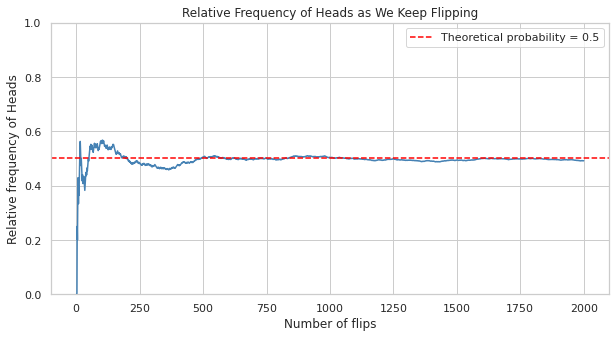

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=flips, x="flip_number", y="relative_freq_so_far", color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", label="Theoretical probability = 0.5")

plt.title("Relative Frequency of Heads as We Keep Flipping")
plt.xlabel("Number of flips")
plt.ylabel("Relative frequency of Heads")
plt.ylim(0, 1)
plt.legend()
plt.show()

At the beginning, the line jumps all over the place. As the flips pile up, it settles down closer and closer to the red line.

Is this just luck? Let's try it **five times** and see if every run behaves the same way.

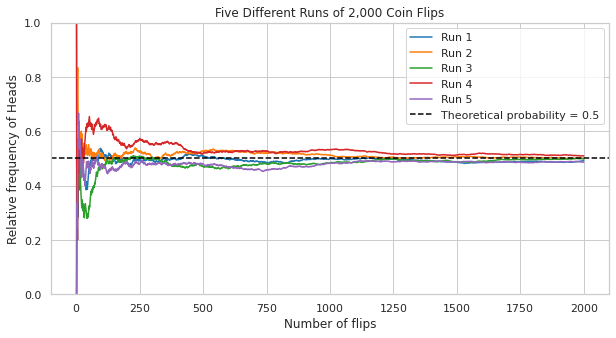

In [15]:
all_runs = []

for run in range(1, 6):
    one_run = flip_coins(2000)
    one_run["relative_freq_so_far"] = one_run["value"].cumsum() / one_run["flip_number"]
    one_run["run"] = f"Run {run}"
    all_runs.append(one_run)

all_runs = pd.concat(all_runs, ignore_index=True)   # renumber rows so no labels repeat

plt.figure(figsize=(10, 5))
sns.lineplot(data=all_runs, x="flip_number", y="relative_freq_so_far", hue="run", palette="tab10")
plt.axhline(0.5, color="black", linestyle="--", label="Theoretical probability = 0.5")

plt.title("Five Different Runs of 2,000 Coin Flips")
plt.xlabel("Number of flips")
plt.ylabel("Relative frequency of Heads")
plt.ylim(0, 1)
plt.legend()
plt.show()

Every run starts out messy and different, but they all **squeeze toward 0.5** as the number of flips grows.

### 💡 The big idea:
When trials are **independent** (one flip doesn't affect the next one), the more trials you do, the closer the relative frequency gets to **one single value**.

### 💡 What probability really means
That single value the relative frequency settles on *is* the probability. The **probability** of an outcome is its **long-run relative frequency** — what fraction of the time it happens if you repeat the process a huge number of times.

So when we say P(Heads) = 0.5, we **don't** mean "every 2 flips you'll get exactly 1 head." We mean "in the long run, about half of all flips will be heads."

### ⚠️ A common mistake
Suppose you flip 5 tails in a row. Is Heads now "due"? **No!** The coin has no memory. The next flip is still a 50-50 chance. The law of large numbers works because the early streaks get *drowned out* by thousands of later flips — not because the coin "fixes" them.

---
## The Complement

### What is a complement? *(2.4.A.4)*
The **complement** of an event E is **everything in the sample space that is *not* in E**. It's the event "E does **not** happen."

You might see it written a few different ways — they all mean the same thing:

$$E' \qquad \bar{E} \qquad E^C$$

### Why does it work?
An event and its complement **split the sample space into two pieces** that don't overlap. Every outcome is in exactly one of them. Since the whole sample space has probability **1**:

$$P(E) + P(E') = 1$$

Subtract P(E) from both sides and you get the **complement rule**:

$$\boxed{P(E') = 1 - P(E)}$$

### Example:
- E = "Heads," so E′ = "not Heads" = "Tails"
- P(E′) = 1 − P(Heads) = 1 − 0.5 = **0.5**

### 💡 Why the complement is useful
Sometimes it's **much easier** to find the probability that something *doesn't* happen.

Imagine flipping **10 coins** and asking: *What's the probability of getting at least one Heads?* "At least one" could mean 1 head, 2 heads, 3 heads... all the way to 10. That's a lot of counting!

But the complement — "**no** Heads at all" — is just **one** outcome: all tails. Out of 2¹⁰ = 1,024 equally likely outcomes, that's 1/1,024. So:

$$P(\text{at least one Heads}) = 1 - \frac{1}{1024} \approx 0.999$$

Let's simulate it to check.

In [17]:
number_of_trials = 10_000

# Each row is one trial of flipping 10 coins (1 = Heads, 0 = Tails)
ten_coins = rng.integers(0, 2, size=(number_of_trials, 10))
heads_per_trial = ten_coins.sum(axis=1)

simulated = (heads_per_trial >= 1).mean()
theoretical = 1 - 1/1024

print(f"Simulated P(at least one Heads in 10 flips): {simulated:.4f}")
print(f"Using the complement rule:                   {theoretical:.4f}")

Simulated P(at least one Heads in 10 flips): 0.9985
Using the complement rule:                   0.9990


### That's it! 
Complete the Dice_Template activity with your knowledge of empirical and theoretical probability.